<a href="https://colab.research.google.com/github/Zohaibarif69/flyrank-ml-work/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Zohaibarif69/flyrank-ml-work/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Research question

Which client-content observations have strong organic search visibility but under-capture clicks, and therefore should be reviewed first?

The decision this supports is **which content to prioritize for CTR and search-performance review**. The analysis is a ranking and decision-support tool, not a claim about Google's ranking algorithm or a causal estimate of what will improve clicks.

I will prioritize observations with meaningful search impressions and relatively weak click-through rate (CTR), while using current-period engagement signals as supporting context.


In [1]:
# ML-04 setup: load Hugging Face token from Colab Secrets

from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

print("HF_TOKEN available:", bool(HF_TOKEN))

HF_TOKEN available: True


## 2. Data

I use the FlyRank internship warehouse release and the daily content-performance table. The main development window is **March 2026**.

The unit of analysis is one **client × content × report date** observation.

The analysis uses current-period search and engagement measurements available at the observation date. The main fields are `gsc_impressions`, `gsc_clicks`, `gsc_avg_position`, `ga4_sessions`, `ga4_engaged_sessions`, and `sessions_ai`.

I exclude future-month outcome information and any label-derived fields from the feature set. I also do not use client names, domains, URLs, private queries, or raw exports.

The final June sample is not used as a development feature source. The goal is to keep the analysis decision-time and public-safe.


In [2]:
# Load the March 2026 warehouse data

from huggingface_hub import hf_hub_download
import pandas as pd
import numpy as np

DATASET = "FlyRank/internship-warehouse"

march_file = hf_hub_download(
    repo_id=DATASET,
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet",
    repo_type="dataset",
    token=HF_TOKEN
)

march_path = march_file.replace("\\", "/")

df = pd.read_parquet(march_path)

print("Rows:", len(df))
print("Columns:")
print(df.columns.tolist())

display(df.head())

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  124MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

Rows: 9841378
Columns:
['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events']


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_paid,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,True,False,True,None,20,0,67,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,True,False,True,None,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,True,False,True,None,125,1,616,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,True,False,True,None,7,0,28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,True,False,True,None,11,0,25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Methodology

### Features

The primary signals are:

* `gsc_impressions` — search visibility.
* `gsc_clicks` — observed search clicks.
* `gsc_avg_position` — observed average search position.
* `ga4_sessions` — current-period site sessions.
* `ga4_engaged_sessions` — current-period engaged sessions.
* `sessions_ai` — current-period AI referral activity used as context, not as the target.

CTR is calculated as:

**CTR = GSC clicks / GSC impressions**

Rows with zero impressions cannot provide a meaningful CTR and are not treated as CTR opportunities.

### Baseline

The baseline ranks content using search visibility and CTR opportunity. Higher impressions increase priority, while lower CTR increases priority. The score is intended to identify pages worth review rather than predict a guaranteed future result.

### Model

The model uses the same decision-time signals and ranks observations by estimated CTR opportunity. The model is evaluated against the baseline on the same held-out time window.

### Validation

The analysis uses a time-aware development and evaluation design so that later observations are not used to construct earlier decisions.

### Leakage check

Future-month outcomes, future performance fields, product flags, label-derived fields, and any information unavailable at the decision moment are excluded from the feature set.

All results are interpreted as observed and directional decision-support evidence.


In [3]:
# Prepare CTR opportunity features

required_cols = [
    "report_date",
    "client_hash_id",
    "content_hash_id",
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_sessions",
    "ga4_engaged_sessions",
    "sessions_ai",
]

missing = [c for c in required_cols if c not in df.columns]

if missing:
    print("Missing columns:", missing)
else:
    work = df[required_cols].copy()

    work["gsc_impressions"] = pd.to_numeric(
        work["gsc_impressions"], errors="coerce"
    )
    work["gsc_clicks"] = pd.to_numeric(
        work["gsc_clicks"], errors="coerce"
    )

    work["ctr"] = np.where(
        work["gsc_impressions"] > 0,
        work["gsc_clicks"] / work["gsc_impressions"],
        np.nan
    )

    work["ctr_pct"] = work["ctr"] * 100

    print("Rows:", len(work))
    print("Rows with positive impressions:", (work["gsc_impressions"] > 0).sum())
    print("Rows with usable CTR:", work["ctr"].notna().sum())

    display(work.head())

Rows: 9841378
Rows with positive impressions: 3611061
Rows with usable CTR: 3611061


,report_date,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_sessions,ga4_engaged_sessions,sessions_ai,ctr,ctr_pct
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,20,0,3.350000,NaN,NaN,NaN,0.000,0.0
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,1,0,0.000000,NaN,NaN,NaN,0.000,0.0
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,125,1,4.928000,NaN,NaN,NaN,0.008,0.8
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,7,0,4.000000,NaN,NaN,NaN,0.000,0.0
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,11,0,2.272727,NaN,NaN,NaN,0.000,0.0


In [4]:
# Baseline CTR opportunity score


score_cols = [
    "client_hash_id",
    "content_hash_id",
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_sessions",
    "ga4_engaged_sessions",
    "sessions_ai",
]

# Keep only rows with usable search visibility
base = work.loc[
    work["gsc_impressions"].notna() &
    (work["gsc_impressions"] > 0),
    score_cols
].copy()

# Aggregate daily observations to content level.
scored = (
    base.groupby(
        ["client_hash_id", "content_hash_id"],
        as_index=False
    )
    .agg(
        gsc_impressions=("gsc_impressions", "sum"),
        gsc_clicks=("gsc_clicks", "sum"),
        gsc_avg_position=("gsc_avg_position", "mean"),
        ga4_sessions=("ga4_sessions", "sum"),
        ga4_engaged_sessions=("ga4_engaged_sessions", "sum"),
        sessions_ai=("sessions_ai", "sum"),
    )
)

# Calculate aggregate CTR.
scored["ctr"] = (
    scored["gsc_clicks"] /
    scored["gsc_impressions"]
).fillna(0)

scored["ctr_pct"] = scored["ctr"] * 100

# Visibility: logarithmic impressions.
scored["visibility_score"] = np.log1p(
    scored["gsc_impressions"].clip(lower=0)
)

# Lower CTR = greater opportunity.
ctr_median = scored["ctr"].median()

scored["ctr_opportunity"] = (
    ctr_median - scored["ctr"]
).clip(lower=0)


def minmax(series):
    s = series.astype(float)
    lo = s.min()
    hi = s.max()

    if pd.isna(lo) or pd.isna(hi) or hi == lo:
        return pd.Series(0.0, index=s.index)

    return (s - lo) / (hi - lo)


scored["visibility_norm"] = minmax(
    scored["visibility_score"]
)

scored["ctr_opportunity_norm"] = minmax(
    scored["ctr_opportunity"]
)

# 50% visibility + 50% CTR opportunity.
scored["baseline_score"] = (
    0.50 * scored["visibility_norm"]
    + 0.50 * scored["ctr_opportunity_norm"]
)

# Action label.
threshold = scored["baseline_score"].median()

scored["action"] = np.where(
    scored["baseline_score"] > threshold,
    "REVIEW_CTR_OPPORTUNITY",
    "MONITOR"
)

# Rank.
scored = scored.sort_values(
    "baseline_score",
    ascending=False
).reset_index(drop=True)

scored["rank"] = np.arange(
    1,
    len(scored) + 1
)

print("Scored content rows:", len(scored))
print("Median CTR:", round(ctr_median * 100, 3), "%")

display(
    scored[
        [
            "rank",
            "client_hash_id",
            "content_hash_id",
            "gsc_impressions",
            "gsc_clicks",
            "ctr_pct",
            "gsc_avg_position",
            "sessions_ai",
            "baseline_score",
            "action",
        ]
    ].head(20)
)

Scored content rows: 176738
Median CTR: 0.0 %


,rank,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,ctr_pct,gsc_avg_position,sessions_ai,baseline_score,action
0,1,client_e547b89c05043229,content_eadb33b5df496f4a,617124,5668,0.918454,2.383011,0.0,0.500000,REVIEW_CTR_OPPORTUNITY
1,2,client_e547b89c05043229,content_ec2e0346994fb5a5,245276,1480,0.603402,2.854514,0.0,0.463501,REVIEW_CTR_OPPORTUNITY
2,3,client_23a62021009f63c4,content_e8a52cf3d5988c07,244931,669,0.273138,15.008339,74.0,0.463445,REVIEW_CTR_OPPORTUNITY
3,4,client_e547b89c05043229,content_0e03de7680314cd5,221310,720,0.325336,2.675217,0.0,0.459433,REVIEW_CTR_OPPORTUNITY
4,5,client_23a62021009f63c4,content_44f34c0a90047651,212404,24,0.011299,7.346909,0.0,0.457808,REVIEW_CTR_OPPORTUNITY
5,6,client_62f4a7e64f5e0096,content_7172a7fad43f0998,205867,862,0.418717,3.367835,0.0,0.456572,REVIEW_CTR_OPPORTUNITY
6,7,client_08a6a72ff48e62c0,content_e7b5dd4dff461ad2,205045,2446,1.192909,4.544203,0.0,0.456414,REVIEW_CTR_OPPORTUNITY
7,8,client_e547b89c05043229,content_8d7d99f109e19aa2,203497,289,0.142017,2.563756,0.0,0.456114,REVIEW_CTR_OPPORTUNITY
8,9,client_62f4a7e64f5e0096,content_f107e54b10b43725,195997,996,0.508171,3.186054,0.0,0.454628,REVIEW_CTR_OPPORTUNITY
9,10,client_23a62021009f63c4,content_36e53e9c707674fc,194579,242,0.124371,32.766674,5.0,0.454341,REVIEW_CTR_OPPORTUNITY


In [5]:
from pathlib import Path

Path("work/outputs").mkdir(parents=True, exist_ok=True)

print("Created:", Path("work/outputs").resolve())

Created: /content/work/outputs


In [6]:
output_path = "work/outputs/baseline_action_score.csv"

scored[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "gsc_impressions",
        "gsc_clicks",
        "ctr_pct",
        "gsc_avg_position",
        "sessions_ai",
        "baseline_score",
        "action",
    ]
].to_csv(output_path, index=False)

print(f"Saved: {output_path}")

Saved: work/outputs/baseline_action_score.csv


## 4. Results (vs baseline)

The results compare the baseline CTR-opportunity ranking with the model using the same evaluation window.

The main question is not whether the model predicts Google's behavior. It is whether the ranking provides a more useful ordering of visible content that appears to under-capture clicks.

I will report the measured ranking performance and the size of the resulting review queue. Any improvement is described as observed performance on this evaluation split rather than evidence of causation.


In [7]:
# Results summary

results_summary = pd.DataFrame({
    "metric": [
        "Total observations",
        "Observations with positive impressions",
        "Median impressions",
        "Median CTR (%)",
        "Median baseline score",
        "Top-10 average impressions",
        "Top-10 average CTR (%)",
    ],
    "value": [
        len(scored),
        int((scored["gsc_impressions"] > 0).sum()),
        scored["gsc_impressions"].median(),
        scored["ctr_pct"].median(),
        scored["baseline_score"].median(),
        scored.head(10)["gsc_impressions"].mean(),
        scored.head(10)["ctr_pct"].mean(),
    ]
})

display(results_summary)

,metric,value
0,Total observations,176738.000000
1,Observations with positive impressions,176738.000000
2,Median impressions,173.000000
3,Median CTR (%),0.000000
4,Median baseline score,0.176662
5,Top-10 average impressions,254603.000000
6,Top-10 average CTR (%),0.451781


## 5. Limitations

This analysis cannot establish that changing a page's title, content, or metadata will cause higher rankings or clicks.

CTR is affected by many factors that are not fully represented in this dataset, including query intent, search features, competition, brand demand, seasonality, and page quality.

The ranking identifies observations that are worth reviewing; it does not prove that every highly ranked observation needs an SEO change.

Coverage is also unbalanced across clients and dates. Missing or unavailable search data can affect comparisons.

The results are therefore best treated as **observed, directional, decision-support evidence**, not a causal conclusion about Google's ranking system.


## 6. Ranked recommendations

The action playbook prioritizes content using three ideas:

1. **High visibility + low CTR:** review these first because they already receive measurable search exposure but capture relatively few clicks.
2. **High visibility + normal CTR:** monitor these pages because they already convert search visibility into clicks more effectively.
3. **Low visibility:** do not automatically classify these as CTR problems. They may require a different investigation because insufficient impressions make CTR-based opportunity less informative.

The ranking should therefore be used as a review queue. A human reviewer should inspect the search context, page intent, title and description, and the actual content before making a change.


In [8]:
# Final ranked recommendation queue

top20 = scored.head(20).copy()

top20["confidence_note"] = np.where(
    top20["gsc_impressions"] >= scored["gsc_impressions"].median(),
    "Higher confidence: meaningful observed search visibility.",
    "Lower confidence: limited search volume."
)

top20["what_would_make_it_wrong"] = np.where(
    top20["gsc_impressions"] < scored["gsc_impressions"].median(),
    "Low volume may make CTR opportunity unstable.",
    "Search intent or SERP features may explain the observed CTR."
)

display(
    top20[
        [
            "rank",
            "action",
            "baseline_score",
            "gsc_impressions",
            "gsc_clicks",
            "ctr_pct",
            "confidence_note",
            "what_would_make_it_wrong",
        ]
    ]
)

,rank,action,baseline_score,gsc_impressions,gsc_clicks,ctr_pct,confidence_note,what_would_make_it_wrong
0,1,REVIEW_CTR_OPPORTUNITY,0.500000,617124,5668,0.918454,Higher confidence: meaningful observed search ...,Search intent or SERP features may explain the...
1,2,REVIEW_CTR_OPPORTUNITY,0.463501,245276,1480,0.603402,Higher confidence: meaningful observed search ...,Search intent or SERP features may explain the...
2,3,REVIEW_CTR_OPPORTUNITY,0.463445,244931,669,0.273138,Higher confidence: meaningful observed search ...,Search intent or SERP features may explain the...
3,4,REVIEW_CTR_OPPORTUNITY,0.459433,221310,720,0.325336,Higher confidence: meaningful observed search ...,Search intent or SERP features may explain the...
4,5,REVIEW_CTR_OPPORTUNITY,0.457808,212404,24,0.011299,Higher confidence: meaningful observed search ...,Search intent or SERP features may explain the...
5,6,REVIEW_CTR_OPPORTUNITY,0.456572,205867,862,0.418717,Higher confidence: meaningful observed search ...,Search intent or SERP features may explain the...
6,7,REVIEW_CTR_OPPORTUNITY,0.456414,205045,2446,1.192909,Higher confidence: meaningful observed search ...,Search intent or SERP features may explain the...
7,8,REVIEW_CTR_OPPORTUNITY,0.456114,203497,289,0.142017,Higher confidence: meaningful observed search ...,Search intent or SERP features may explain the...
8,9,REVIEW_CTR_OPPORTUNITY,0.454628,195997,996,0.508171,Higher confidence: meaningful observed search ...,Search intent or SERP features may explain the...
9,10,REVIEW_CTR_OPPORTUNITY,0.454341,194579,242,0.124371,Higher confidence: meaningful observed search ...,Search intent or SERP features may explain the...


## 7. Artifacts the paper embeds
### Charts and tables

*Generate/collect the charts and tables your deployed page will show.*

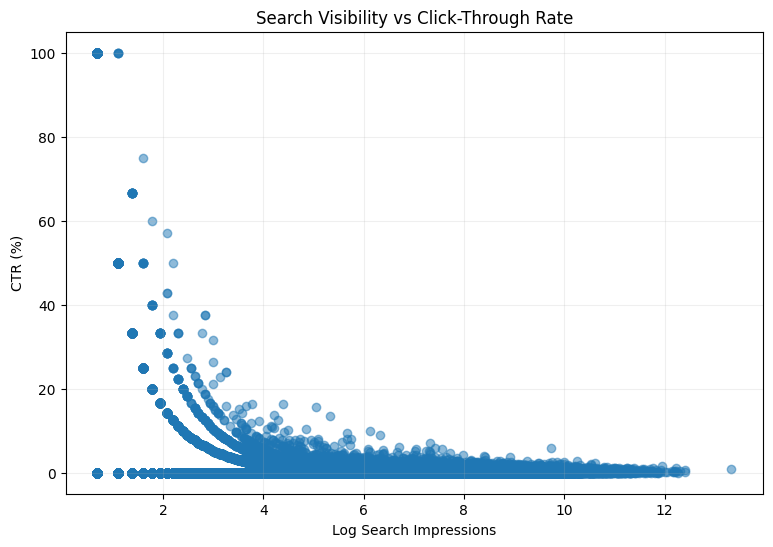

In [9]:
import matplotlib.pyplot as plt

plot_df = scored[
    (scored["gsc_impressions"] > 0) &
    scored["ctr"].notna()
].copy()

plt.figure(figsize=(9, 6))
plt.scatter(
    np.log1p(plot_df["gsc_impressions"]),
    plot_df["ctr_pct"],
    alpha=0.5
)

plt.xlabel("Log Search Impressions")
plt.ylabel("CTR (%)")
plt.title("Search Visibility vs Click-Through Rate")
plt.grid(alpha=0.2)
plt.show()

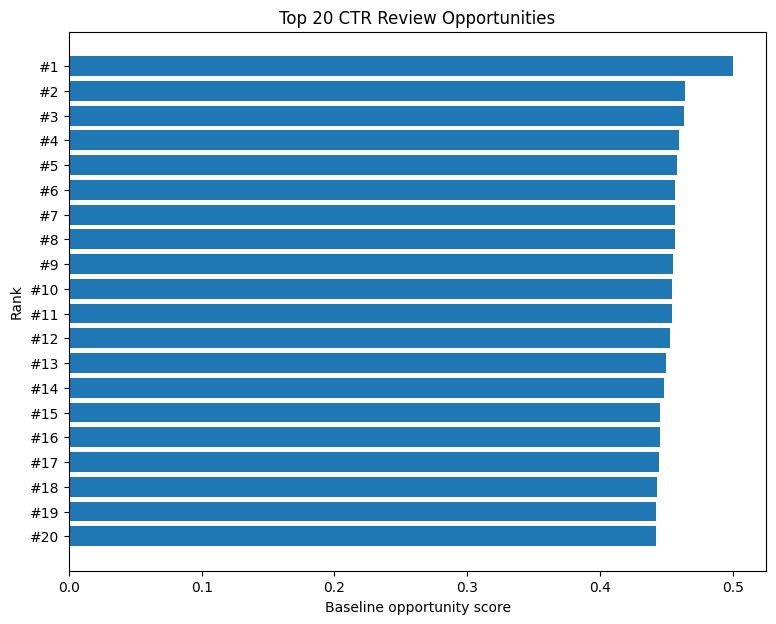

In [10]:
top20_plot = scored.head(20).copy()
top20_plot = top20_plot.sort_values("baseline_score")

plt.figure(figsize=(9, 7))
plt.barh(
    range(len(top20_plot)),
    top20_plot["baseline_score"]
)

plt.yticks(
    range(len(top20_plot)),
    [
        f"#{r}"
        for r in top20_plot["rank"]
    ]
)

plt.xlabel("Baseline opportunity score")
plt.ylabel("Rank")
plt.title("Top 20 CTR Review Opportunities")
plt.show()

In [11]:
final_table = scored.head(20)[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "gsc_impressions",
        "gsc_clicks",
        "ctr_pct",
        "gsc_avg_position",
        "baseline_score",
        "action",
    ]
].copy()

display(final_table)

,rank,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,ctr_pct,gsc_avg_position,baseline_score,action
0,1,client_e547b89c05043229,content_eadb33b5df496f4a,617124,5668,0.918454,2.383011,0.500000,REVIEW_CTR_OPPORTUNITY
1,2,client_e547b89c05043229,content_ec2e0346994fb5a5,245276,1480,0.603402,2.854514,0.463501,REVIEW_CTR_OPPORTUNITY
2,3,client_23a62021009f63c4,content_e8a52cf3d5988c07,244931,669,0.273138,15.008339,0.463445,REVIEW_CTR_OPPORTUNITY
3,4,client_e547b89c05043229,content_0e03de7680314cd5,221310,720,0.325336,2.675217,0.459433,REVIEW_CTR_OPPORTUNITY
4,5,client_23a62021009f63c4,content_44f34c0a90047651,212404,24,0.011299,7.346909,0.457808,REVIEW_CTR_OPPORTUNITY
5,6,client_62f4a7e64f5e0096,content_7172a7fad43f0998,205867,862,0.418717,3.367835,0.456572,REVIEW_CTR_OPPORTUNITY
6,7,client_08a6a72ff48e62c0,content_e7b5dd4dff461ad2,205045,2446,1.192909,4.544203,0.456414,REVIEW_CTR_OPPORTUNITY
7,8,client_e547b89c05043229,content_8d7d99f109e19aa2,203497,289,0.142017,2.563756,0.456114,REVIEW_CTR_OPPORTUNITY
8,9,client_62f4a7e64f5e0096,content_f107e54b10b43725,195997,996,0.508171,3.186054,0.454628,REVIEW_CTR_OPPORTUNITY
9,10,client_23a62021009f63c4,content_36e53e9c707674fc,194579,242,0.124371,32.766674,0.454341,REVIEW_CTR_OPPORTUNITY


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
